# 基于 Embedding 与单层双向 RNN 的 IMDB 情感分类

本 notebook 使用 PyTorch 实现基于词嵌入（Embedding）和**单层双向**循环神经网络（RNN）的文本情感分类模型，在 IMDB 电影评论数据集上完成正面/负面情感的二分类任务。双向 RNN 同时从左向右、从右向左处理序列，能更充分地捕捉上下文语义。

In [1]:
import matplotlib as mpl           # Matplotlib 主模块，用于绘图配置
import matplotlib.pyplot as plt     # pyplot：提供类似 MATLAB 的绘图接口
%matplotlib inline                 
 # Jupyter 魔法命令：将图表直接渲染在 Notebook 中
import numpy as np                  # NumPy：高性能数值计算库
import sklearn                      # Scikit-learn：机器学习工具库（用于 accuracy_score 等）
import pandas as pd                 # Pandas：数据处理与分析库
import os                           # os 模块：操作系统接口（文件/目录操作）
import sys                          # sys 模块：访问 Python 解释器相关信息
import time                         # time 模块：时间相关函数
from tqdm import tqdm          # tqdm：进度条工具，auto 模式自动适配终端/Jupyter
import torch                        # PyTorch 核心模块
import torch.nn as nn               # torch.nn：神经网络模块（层、损失函数等）
import torch.nn.functional as F     # torch.nn.functional：无参数的函数式 API（激活函数、损失等）

# 打印 Python 版本信息
print(sys.version_info)
# 打印各依赖库的版本，便于复现实验环境
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 优先使用 GPU（cuda:0），若不可用则退回 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的设备

seed = 42  # 随机种子，用于保证实验可复现性


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 一、加载 IMDB 数据集

本节通过 HuggingFace `datasets` 库加载 [stanfordnlp/imdb](https://huggingface.co/datasets/stanfordnlp/imdb) 数据集。该数据集包含 **50 000** 条英文电影评论，已划分为训练集 25 000 条、测试集 25 000 条；每条样本包含原始文本 `text` 与情感标签 `label`（0 = 负面，1 = 正面）。与 Keras 预处理后版本不同，此处保留**原始字符串**，便于后续自定义分词与词典构建。

### 1.1 从 HuggingFace 下载并缓存数据集

使用 `load_dataset` 接口自动下载数据到本地 `cache_dir`，避免重复联网。返回值为 `DatasetDict` 类型，可通过键名 `'train'`、`'test'` 访问各子集。

In [2]:
from datasets import load_dataset  # HuggingFace datasets 库：提供 load_dataset 统一数据加载接口

cache_dir = 'data/imdb'  # str：本地缓存目录路径，下载后的 Arrow 文件将保存在此

if not os.path.exists(cache_dir):  # os.path.exists(path) -> bool：判断目录是否已存在
    os.makedirs(cache_dir)  # os.makedirs(path)：递归创建目录（含父目录），已存在时不报错

# load_dataset(name, cache_dir) -> DatasetDict
#   name: 数据集标识符，'stanfordnlp/imdb' 为 Stanford NLP 发布的 IMDB 影评数据集
#   cache_dir: 指定缓存位置，第二次运行将直接读取本地文件，无需重新下载
dataset = load_dataset('stanfordnlp/imdb', cache_dir=cache_dir)

print(type(dataset))  # 预期输出 <class 'datasets.dataset_dict.DatasetDict'>，类似字典，键为 split 名
print(type(dataset['train']['text']))  # 预期输出 Column 类型，存储该列所有文本，支持索引访问

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Column'>


### 1.2 提取训练集与测试集的文本和标签

将 `DatasetDict` 中各 split 的 `text`、`label` 列转为 NumPy 一维数组，便于后续向量化处理与批训练。`label` 为整数 0（负面）或 1（正面）。

In [3]:
# np.array(iterable) -> ndarray：将 Column / 列表转为 NumPy 数组，dtype 由元素类型自动推断
train_texts = np.array(dataset['train']['text'])    # shape=(25000,)，元素为 str，训练集评论原文
train_labels = np.array(dataset['train']['label'])  # shape=(25000,)，元素为 int64，取值 0 或 1
test_texts = np.array(dataset['test']['text'])      # shape=(25000,)，测试集评论原文
test_labels = np.array(dataset['test']['label'])    # shape=(25000,)，测试集情感标签

## 二、构造 word2idx 和 idx2word

在自然语言处理中，模型只能处理数值输入，因此需要将单词映射为整数索引。本节基于**训练集**统计词频、构建有限大小的词典，并预留特殊符号：`<PAD>`（填充）、`<OOV>`（未登录词）、`<BOS>`（句首）、`<EOS>`（句尾）。测试集中未出现在训练词典里的词将统一映射为 `<OOV>`。

### 2.1 文本清洗与分词

对训练文本做简单规范化：将标点替换为空格、合并连续空白，再按空格切分为词列表。仅在训练集上统计词频，避免测试集信息泄露。

In [4]:
from collections import Counter  # Counter：可哈希元素的可变映射，专门用于词频统计；most_common(n) 按频率降序返回最高频 n 项

import re  # re：正则表达式模块，用于复杂字符串模式匹配与替换

def clean_text(text):
    """
    对单条评论做轻量文本清洗。

    参数:
        text (str): 原始电影评论字符串。

    返回:
        str: 清洗后的文本，首尾无多余空白，词与词之间以单个空格分隔。
    """
    text = text.replace(',', ' ').replace('.', ' ')  # 将逗号、句号替换为空格，弱化标点对分词的影响
    text = re.sub(r'\s+', ' ', text)  # re.sub(pattern, repl, s)：将连续空白（空格/换行/制表符）合并为一个空格
    return text.strip()  # str.strip()：去除首尾空白字符，返回新字符串

# 列表推导式：对 train_texts 中每条评论调用 clean_text，再封装为 NumPy 数组
train_texts = np.array([clean_text(t) for t in train_texts])  # shape 仍为 (25000,)，元素为清洗后的 str
test_texts= np.array([clean_text(t) for t in test_texts])   #测试集数据也清洗

all_words = []  # list[str]：存放训练集全部分词结果，用于后续统计词频
for text in train_texts:  # 遍历每条清洗后的评论
    all_words.extend(text.split())  # str.split()：默认按任意空白切分，返回 list[str]；extend 将词追加到 all_words

word_counts = Counter(all_words)  # Counter(all_words) -> Counter：键为单词，值为出现次数

### 2.2 构建 word2idx 与 idx2word 映射

选取词频最高的若干词填入词典（索引从 4 起），并建立反向映射 `idx2word`，便于将整数索引还原为可读单词。超出词典容量的词在编码阶段将映射为 `<OOV>`（索引 1）。

In [5]:
max_vocab_size = 20000  # int：词典总容量上限（含 4 个特殊符号），Embedding 层 num_embeddings 将与此一致

# dict[str, int]：词 -> 索引；索引 0~3 预留给特殊 token，普通词从 4 开始编号
word2idx = {'<PAD>': 0, '<OOV>': 1, '<BOS>': 2, '<EOS>': 3}

# Counter.most_common(n) -> list[tuple[str, int]]：返回频率最高的 n 个 (词, 次数) 元组
# 排序规则：按词频降序（出现次数多的在前，少的在后），频率相同时按首次出现顺序排列
most_common_words = word_counts.most_common(max_vocab_size - 4)  # 预留 4 个位置给特殊符号；列表首项为最高频词

start = 4  # int：普通词汇索引起始值（0~3 已被特殊符号占用）
for idx, (word, count) in enumerate(most_common_words, start=start):
    # enumerate(iterable, start)：同时产出索引 idx 与元素 (word, count)
    # 因 most_common 为降序，idx=4 对应最高频词，idx 越大对应词频越低
    word2idx[word] = idx  # 将高频词写入正向词典，idx 从 4 递增到 max_vocab_size - 1

print(f"词典大小: {len(word2idx)}")  # len(dict) -> int：当前词典中的条目总数

# 字典推导式：由 word2idx 反转得到 idx2word，键为 int 索引，值为 str 单词
idx2word = {idx: word for word, idx in word2idx.items()}  # dict[int, str]

vocab_size = len(word2idx)  # int：词典条目总数，供后续 Embedding 层 num_embeddings 使用

for i in range(10):  # 打印前 10 个索引对应的词，验证特殊符号与普通词编号是否正确
    print(f"{i}: {idx2word[i]}")  # 预期 0~3 为 <PAD>/<OOV>/<BOS>/<EOS>，4 起为高频实词

词典大小: 20000
0: <PAD>
1: <OOV>
2: <BOS>
3: <EOS>
4: the
5: a
6: and
7: of
8: to
9: is


## 三、分析数据长度分布

统计训练集中各评论的单词数（序列长度），可视化其分布，并确定截断/填充的最大长度 `MAX_LENGTH`。

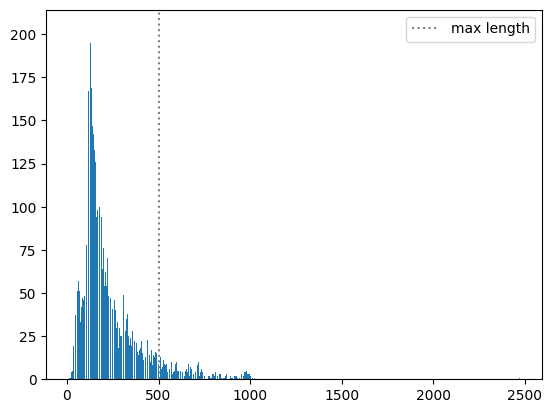

In [6]:
# 选择合适的最大序列长度（max_length）
length_collect = {}  # 用字典存储 {序列长度: 出现次数} 的频率统计

# 遍历训练集中每条评论，统计其长度出现次数
for text in train_texts:
    length = len(text.split())                                       # 获取当前评论的单词数（序列长度）
    length_collect[length] = length_collect.get(length, 0) + 1  # 累计该长度出现次数

# 设置最大序列长度——超过此长度的评论将被截断，短于此长度的将被填充（Padding）
MAX_LENGTH = 500

# 绘制各长度频率的柱状图，横轴为序列长度，纵轴为出现次数
plt.bar(length_collect.keys(), length_collect.values())
# 在 MAX_LENGTH=500 处绘制竖虚线，直观展示截断位置（绝大多数评论长度在 500 以内）
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
plt.legend()  # 显示图例
plt.show()    # 渲染图表

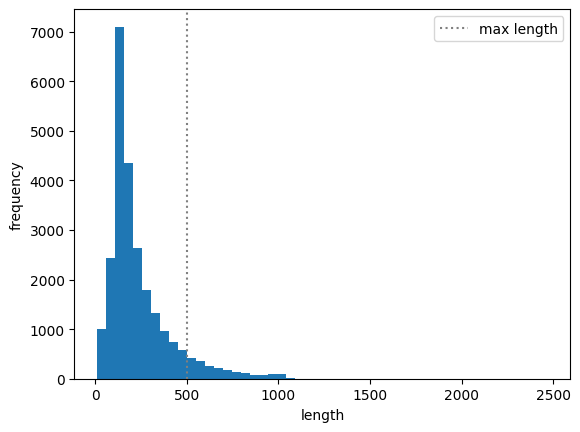

In [7]:
# 用直方图更直观地展示句子长度分布（bins=50 将范围分为 50 个区间）
# 列表推导式：提取每条评论的单词数，生成长度列表
length_list = [len(text.split()) for text in train_texts]  # List[int]，每个元素为对应评论的长度

# 绘制长度分布直方图
plt.hist(length_list, bins=50)       # bins=50：将长度范围均分为 50 个区间
plt.xlabel("length")                 # 横轴：序列长度（单词数）
plt.ylabel("frequency")              # 纵轴：出现频次
plt.axvline(500, label="max length", c="gray", ls=":")  # 在 500 处画竖虚线标注截断点
plt.legend()                         # 显示图例
plt.show()                           # 渲染图表

### 3.1 查看前 10 条样本的长度

In [8]:
# 查看前 10 条训练样本的序列长度
# 返回值：List[int]，例如 [292, 214, 96, ...]
# 可以看到不同评论的长度差异很大，因此需要 Padding 将其统一到相同长度
length_list[0:10]

[292, 214, 96, 121, 325, 123, 114, 303, 486, 224]

In [9]:
# 构造一个用于演示 Tokenizer 功能的原始文本列表（批量输入格式）
# 每个元素都是 List[str]（分词后的单词列表），模拟真实 NLP 管道中的批次数据
raw_text = [
    "hello world".split(),               # 样本 1：["hello", "world"]
    "tokenize text datas with batch".split(),  # 样本 2：5 个单词
    "this is a test".split()             # 样本 3：4 个单词
]
raw_text  # 打印查看批次原始文本结构

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

## 四、Tokenizer

封装一个 `Tokenizer` 类，实现 **编码（Encode）** 和 **解码（Decode）** 两大核心功能：
- **Encode**：将原始文本批次转换为填充后的整数 id 张量
- **Decode**：将整数 id 序列还原为可读文本

**RNN 注意**：

1. **前缀填充**：RNN 应使用 `padding_first=True`。RNN 按时间步递推隐藏状态，若 PAD 放在句末，真实词处理完后 PAD 仍会不断改写已积累的语义，使句末表示被稀释；PAD 放在句首时，有效词依次递推，最后时间步停在句末真实词上，语义保留更完整。

2. **双向句向量取值（易错点）**：双向时 **不能** 直接用 `seq_output[:, -1, :]` 作为句向量。PyTorch 中位置 `t` 的反向输出表示「从句末倒读到 `t`」的信息，因此在末位置 `-1` 反向只看过最后一个词；反向读完整句的状态在首位置 `0`，对应 `final_hidden[-1]`。正确做法是拼接末层正向与反向最终隐状态：`torch.cat([final_hidden[-2], final_hidden[-1]], dim=-1)`。单向时 `final_hidden[-1]` 与 `seq_output[:, -1, :]` 等价。

In [10]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500,
                 pad_idx=0, bos_idx=2, eos_idx=3, unk_idx=1,
                 truncate_mode='adaptive'):
        """
        初始化 Tokenizer（文本编解码器）
        参数：
            word2idx       (Dict[str,int]): 单词 → id 映射字典
            idx2word       (Dict[int,str]): id → 单词 映射字典
            max_length     (int):           序列最大长度，超出则按 truncate_mode 处理，默认 500
            pad_idx        (int):           填充 token 的 id，默认 0
            bos_idx        (int):           句子起始 token 的 id，默认 2
            eos_idx        (int):           句子结束 token 的 id，默认 3
            unk_idx        (int):           未知词 token 的 id，默认 1
            truncate_mode  (str):           超长序列截断策略，默认 'adaptive'
                - 'adaptive'：自适应步长，在全文上等间隔采样 max_length 个 token
                - 'head'    ：保留句首，丢弃末尾（index[:max_length]）
                - 'tail'    ：保留句尾，丢弃开头（index[-max_length:]）
        """
        self.word2idx       = word2idx        # 单词 → id 字典，用于编码
        self.idx2word       = idx2word        # id → 单词 字典，用于解码
        self.max_length     = max_length      # 序列截断/填充的最大长度
        self.pad_idx        = pad_idx         # 填充符 id
        self.bos_idx        = bos_idx         # 句子起始符 id
        self.eos_idx        = eos_idx         # 句子结束符 id
        self.unk_idx        = unk_idx         # 未知词 id
        valid_modes = ('adaptive', 'head', 'tail')  # 允许的截断策略枚举
        if truncate_mode not in valid_modes:
            raise ValueError(f"truncate_mode 必须是 {valid_modes} 之一，当前为 {truncate_mode!r}")
        self.truncate_mode  = truncate_mode   # str：超长序列截断策略

    def _truncate_to_max_length(self, index, max_length):
        """
        将超长 id 序列压缩到 max_length（仅当 len(index) >= max_length 时调用）
        参数：
            index      (List[int]): 单条样本的 token id 列表
            max_length (int):       目标序列长度
        返回：
            List[int]，长度恒为 max_length
        """
        if self.truncate_mode == 'head':
            return index[:max_length]  # 保留句首 max_length 个 token，丢弃末尾
        if self.truncate_mode == 'tail':
            return index[-max_length:]  # 保留句尾 max_length 个 token，丢弃开头
        # adaptive：步长 step ≈ len(index) / max_length，在 [0, len-1] 上等间隔采样
        positions = np.linspace(0, len(index) - 1, max_length, dtype=int)  # ndarray[int]，形状 (max_length,)
        return [index[i] for i in positions]  # List[int]，兼顾首尾与中间信息

    def encode(self, text_list, padding_first=False):
        """
        将文本列表批量编码为整数 id 张量
        参数：
            text_list      (List[List[str]]): 每条文本已拆分为单词列表
            padding_first  (bool):           True 时前缀填充（PAD 在序列头部，避免 RNN 递推时句末语义被 PAD 稀释）；
                                             False 时后缀填充（PAD 在序列尾部，适合池化/CNN 等不依赖最后时间步的模型）
        返回：
            torch.Tensor，形状 (batch_size, seq_len)，dtype=torch.long
        """
        # 动态确定本批次的序列长度（取最长句，但不超过 max_length）
        max_length = min(self.max_length, max(
            [len(text) for text in text_list]))  

        indices = []
        for text in text_list:
            index = [self.word2idx.get(word, self.unk_idx) for word in text]  # 单词 → id
            if len(index) < max_length:
                pad_len = max_length - len(index)  # int：需要补充的 PAD 个数
                if padding_first:
                    index = [self.pad_idx] * pad_len + index  # 前缀填充：PAD 在前，有效词靠后，避免句末语义被稀释
                else:
                    index = index + [self.pad_idx] * pad_len  # 后缀填充：PAD 追加在序列尾部
            else:
                index = self._truncate_to_max_length(index, max_length)  # 按 truncate_mode 处理超长序列
            indices.append(index)
        return torch.tensor(indices)  # List[List[int]] → 2D Tensor

    def decode(self, indices_list, remove_pad=True, split=False):
        """
        将整数 id 序列还原为文本
        参数：
            indices_list (List[List[int]]): 每条样本的 id 序列
            remove_pad   (bool): 是否跳过 PAD ，默认 True（前缀 PAD 跳过，后缀 PAD 遇则停止）
            split        (bool): False 返回字符串；True 返回单词列表
        返回：List[str] 或 List[List[str]]
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "<UNK>")  # id → 单词
                if remove_pad and word == "<PAD>":
                    if text:  # 已有有效词后遇到 PAD，说明是后缀填充，停止解码
                        break
                    continue  # 跳过前缀 PAD
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list


# 实例化 Tokenizer；truncate_mode 可选 'adaptive'（默认）、'head'、'tail'
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, truncate_mode='adaptive')

# 测试示例文本的编码效果（RNN 使用 padding_first=True，前缀填充以保留句末有效语义）
raw_text = ["hello world".split(),
            "tokenize text datas with batch".split(),
            "this is a test".split()]
indices = tokenizer.encode(raw_text, padding_first=True)  # encode 支持批量处理与前缀填充

print("raw text:")  # 打印原始文本
for raw in raw_text:
    print(raw)
print("\n")
print("indices:")   # 打印编码后的 id 张量
for index in indices:
    print(index)
print("\n")


raw text:
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']


indices:
tensor([    0,     0,     0, 14989,   229])
tensor([   1, 3166,    1,   19,    1])
tensor([   0,   14,    9,    5, 2429])




In [11]:
# 演示 decode：将编码后的 id 张量还原为文本
# remove_bos/eos/pad 均设为 False，可看到特殊 token 的位置
decode_text = tokenizer.decode(indices.tolist())  # 保留填充符 [PAD]
print("decode text----------")
for decode in decode_text:
    print(decode)  # 每行为一条解码文本


decode text----------
hello world
<OOV> text <OOV> with <OOV>
this is a test


## 五、数据集与 DataLoader

封装 `IMDBDataset` 与 `collate_fct`，将 Tokenizer 编码集成到数据加载流程中。

In [12]:
from torch.utils.data import Dataset, DataLoader
# Dataset：自定义数据集基类，需实现 __len__ 和 __getitem__
# DataLoader：批量数据加载器


class IMDBDataset(Dataset):
    def __init__(self, data, labels):
        """
        参数：
            data          (np.ndarray): 样本文本数组（每个元素为str）
            labels        (np.ndarray): 情感标签数组（0 或 1）
        """
        self.data = data      # 样本文本数组
        self.labels = labels  # 标签数组

    def __getitem__(self, index):
        """按索引取一条样本，返回 (text: str, label: int)"""
        text  = self.data[index]     
        label = self.labels[index]   
        return text, label

    def __len__(self):
        """返回数据集样本总数（int）"""
        return len(self.data)


def collate_fct(batch):
    """
    DataLoader 的自定义整理函数（collate function）
    将一个 batch 的样本转换为 Tensor，同时完成 Tokenizer 编码。
    参数：
        batch (List[Tuple[str, int]]): 每个元素为 (文本字符串, 标签整数 0/1)
    返回：
        text_tensor  (Tensor): 形状 (batch_size, seq_len)，dtype=torch.int32，供 Embedding 层输入
        label_tensor (Tensor): 形状 (batch_size, 1)，dtype=torch.float32，供 BCE 损失计算
    说明（标签维度变换的必要性）：
        - label_list 经 torch.tensor 后默认形状为 (batch_size,)，是一维向量
        - 本模型最后一层 nn.Linear(hidden_dim, 1)，输出 logits 形状为 (batch_size, 1)
        - F.binary_cross_entropy_with_logits 要求 input 与 target 形状一致，故需 reshape(-1, 1)
        - 其中 -1 表示自动推断 batch 维大小；-1 维的 1 表示二分类仅有 1 个输出 logit
        - .to(dtype=torch.float) 将整数标签 0/1 转为浮点 0.0/1.0，满足 BCE 对 target 类型的要求
    """
    text_list  = [item[0].split() for item in batch]  # List[List[str]]：将每条文本按空格拆成单词列表
    label_list = [item[1] for item in batch]           # List[int]：提取本 batch 的情感标签（0=负面，1=正面）
    # padding_first=True：前缀填充，避免 RNN 在句末 PAD 上递推稀释有效语义，最后时间步对应句末真实词
    text_list  = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)  # Tensor(batch_size, seq_len)
    label_tensor = torch.tensor(label_list)            # Tensor(batch_size,)：列表 → 一维张量，形状如 (64,)
    label_tensor = label_tensor.reshape(-1, 1)         # Tensor(batch_size, 1)：升维为二维，与模型 logits 形状对齐
    label_tensor = label_tensor.to(dtype=torch.float)  # Tensor(batch_size, 1), float32：供 binary_cross_entropy_with_logits 使用
    return text_list, label_tensor                     # 返回 (文本张量, 标签张量) 元组，供训练循环解包


# 实例化训练集和测试集
train_ds = IMDBDataset(train_texts,train_labels)  # 训练集：25000 条
test_ds  = IMDBDataset(test_texts,  test_labels)   # 测试集：25000 条


In [13]:
batch_size = 64  # 每个 mini-batch 的样本数

# 训练集 DataLoader：每轮打乱顺序（shuffle=True），防止模型记住样本顺序
# collate_fn 指定自定义整理函数，将字符串列表转为 Tensor
train_dl = DataLoader(train_ds, batch_size=batch_size,
                      shuffle=True,  collate_fn=collate_fct)
# 测试集 DataLoader：不打乱（shuffle=False），保持顺序以便复现
test_dl  = DataLoader(test_ds,  batch_size=batch_size*2,
                      shuffle=False, collate_fn=collate_fct)


In [14]:
# 验证每个 batch 的形状是否符合预期
# 期望：text 形状 (64, seq_len)，label 形状 (64, 1)
# 注意：由于动态 padding，不同 batch 的 seq_len 可能不同
i = 0
for text, label in train_dl:
    print(text.shape, label.shape)  # 打印 batch 的文本和标签形状
    i += 1
    if i == 50:   # 只打印前 50 个 batch，避免输出过多
        break


torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([

## 六、定义模型


### 6.1 RNN 模型定义

In [15]:
class RNN(nn.Module):
    """
    基于 Embedding + RNN 的情感分类模型。

    架构流程：词嵌入层 → RNN 层 → 全连接投影层 → ReLU → AlphaDropout → 分类输出层
    输出为未经 sigmoid 的原始 logit，与 binary_cross_entropy_with_logits 配合使用。
    """

    def __init__(self, embedding_dim=128, hidden_dim=155, vocab_size=vocab_size, num_layers=1, bidirectional=True, dropout_p=0.5):
        """
        参数：
            embedding_dim (int)：词向量维度，控制每个词的稠密表示容量；默认 128
            hidden_dim (int)：RNN 隐藏状态维度，控制序列建模能力；默认 155
            vocab_size (int)：词汇表大小，决定 Embedding 查找表的行数；默认使用全局变量
            num_layers (int)：RNN 的堆叠层数，层数越多模型越复杂，但也更容易过拟合；默认 1
            bidirectional (bool)：True 则使用双向 RNN（同时正向和反向处理序列）；默认 True（本 notebook 采用单层双向配置）
            dropout_p (float)：AlphaDropout 失活概率，用于减轻全连接层过拟合；默认 0.3
        """
        super().__init__()  # 调用父类 nn.Module 的构造函数，初始化内部状态

        # nn.Embedding：词嵌入查找表，将离散整数索引映射为连续稠密向量
        # 参数：(vocab_size, embedding_dim)，可训练，模型会学习最优词表示
        self.embeding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)

        # nn.RNN：基本 Vanilla RNN 层，逐时间步处理序列
        # batch_first=True：输入维度顺序为 (batch, seq_len, input_size)，更直观易读
        # bidirectional=True 时正向和反向各有一套权重，输出维度变为 hidden_dim * 2
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=bidirectional)

        # 全连接投影层：将 RNN 输出维度统一到 hidden_dim
        # 双向时 RNN 输出为 hidden_dim*2，需要降维；单向时维度不变
        self.layer = nn.Linear(hidden_dim * (2 if bidirectional else 1), hidden_dim)

        # nn.AlphaDropout：专为自归一化网络（SELU）设计的 Dropout，训练时随机置零并保持均值/方差不变
        # 参数 p (float)：元素被置零的概率；eval 模式下自动关闭，等价于恒等映射
        self.dropout = nn.AlphaDropout(p=dropout_p)

        # 分类输出层：将 hidden_dim 维特征映射为 1 维 logit（正面情感得分）
        # 不使用 sigmoid，直接输出 logit，配合 binary_cross_entropy_with_logits 数值更稳定
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        前向传播。

        参数：
            x (torch.Tensor)：词索引张量，shape=(batch_size, seq_len)，dtype=int/long
        返回：
            torch.Tensor：分类 logit，shape=(batch_size, 1)
        """
        # 词嵌入查表：将整数索引序列转换为词向量序列
        # 输入 shape：(batch_size, seq_len)
        # 输出 shape：(batch_size, seq_len, embedding_dim)
        x = self.embeding(x)

        # RNN 前向计算：逐时间步更新隐藏状态
        # seq_output shape：(batch_size, seq_len, hidden_dim * num_directions)，每步输出
        # final_hidden shape：(num_layers * num_directions, batch_size, hidden_dim)，最终隐藏状态
        seq_output, final_hidden = self.rnn(x)

        # 从 RNN 输出中提取整句语义向量（句向量），供后续全连接层分类
        # 前缀填充（padding_first=True）使 PAD 在句首、有效词在句末，正向末时间步可保留完整句意
        if self.rnn.bidirectional:
            # 双向 RNN：正向与反向各取「读完整句」后的最终隐状态，二者并不等价于 seq_output[:, -1, :]
            # PyTorch 约定：位置 t 的反向输出 = 从句末倒读到 t 的信息
            #   - 正向在末位置 -1：从左到右读完整句 → 与 final_hidden[-2] 一致
            #   - 反向在末位置 -1：仅看过最后一个词，信息极少（常见误区：误以为双向都在 -1 看了整句）
            #   - 反向在首位置  0：从右到左读完整句 → 与 final_hidden[-1] 一致
            # final_hidden[-2]：末层正向最终隐状态，shape=(batch_size, hidden_dim)
            # final_hidden[-1]：末层反向最终隐状态，shape=(batch_size, hidden_dim)
            x = torch.cat([final_hidden[-2], final_hidden[-1]], dim=-1)  # shape=(batch_size, hidden_dim*2)
        else:
            # 单向 RNN：末时间步输出seq_output[:, -1, :]与 final_hidden[-1] 等价，直接取末层最终隐状态
            x = final_hidden[-1]  # shape=(batch_size, hidden_dim)

        # 通过全连接层进行维度变换，整合特征
        x = self.layer(x)  # shape：(batch_size, hidden_dim)

        # ReLU 非线性激活：引入非线性表达能力，将负值置零、正值保留
        x = F.relu(x)  # shape：(batch_size, hidden_dim)，与输入形状相同

        # AlphaDropout 正则：训练时随机丢弃部分隐层神经元以减轻过拟合；eval 模式下为恒等映射
        x = self.dropout(x)  # shape：(batch_size, hidden_dim)，形状不变

        # 映射到 1 维 logit，表示该评论为正面情感的未归一化得分
        x = self.fc(x)  # shape：(batch_size, 1)
        return x


# 打印默认配置（单层双向 RNN）的各参数名称及参数量，验证模型结构
print("{:=^80}".format(" 单层双向 RNN "))  # 格式化标题：用 = 填充到 80 字符宽度
for key, value in RNN().named_parameters():  # named_parameters() 返回 (参数名, 参数张量) 迭代器
    # np.prod(value.shape) 计算张量各维度乘积，即该参数的标量总数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

    

#
#
# print("{:=^80}".format(" 双层单向 RNN "))
# for key, value in RNN(num_layers=2).named_parameters():
#     print(f"{key:^40}paramerters num: {np.prod(value.shape)}")


=================================== 单层双向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 19840
            rnn.weight_hh_l0            paramerters num: 24025
             rnn.bias_ih_l0             paramerters num: 155
             rnn.bias_hh_l0             paramerters num: 155
        rnn.weight_ih_l0_reverse        paramerters num: 19840
        rnn.weight_hh_l0_reverse        paramerters num: 24025
         rnn.bias_ih_l0_reverse         paramerters num: 155
         rnn.bias_hh_l0_reverse         paramerters num: 155
              layer.weight              paramerters num: 48050
               layer.bias               paramerters num: 155
               fc.weight                paramerters num: 155
                fc.bias                 paramerters num: 1


### 6.2 各配置参数量统计对比

In [16]:
# 验证参数量计算：RNN 隐藏状态转移矩阵 W_hh 的参数数量
# hidden_dim × hidden_dim = 155 × 155 = 24025
# W_hh 负责将上一时间步的隐藏状态映射到当前隐藏状态，是 RNN 中循环连接的核心参数
155*155

24025

In [17]:
# 打印单层单向 RNN（bidirectional=False）各参数名称与参数量，与默认双向配置对比
# 单向 RNN 仅有一套正向权重，参数量约为双向的一半
# 全连接投影层 layer 的输入维度为 hidden_dim，无需拼接正反向隐状态
print("{:=^80}".format(" 单层单向 RNN "))  # 格式化打印分隔标题
for key, value in RNN(bidirectional=False).named_parameters():  # 显式指定单向，用于与默认双向对比
    # np.prod(value.shape) 计算该参数张量所有维度的乘积，即参数标量总数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

=================================== 单层单向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 19840
            rnn.weight_hh_l0            paramerters num: 24025
             rnn.bias_ih_l0             paramerters num: 155
             rnn.bias_hh_l0             paramerters num: 155
              layer.weight              paramerters num: 24025
               layer.bias               paramerters num: 155
               fc.weight                paramerters num: 155
                fc.bias                 paramerters num: 1


In [18]:
# 打印双层单向 RNN（num_layers=2）各参数名称与参数量
# 第二层 RNN 的输入维度等于第一层的输出维度（hidden_dim），
# 因此第二层的输入权重矩阵 W_ih_l1 形状为 (hidden_dim, hidden_dim) = (155, 155)，参数量为 24025
# 而第一层 W_ih_l0 形状为 (embedding_dim, hidden_dim) = (128, 155)，参数量仅为 19840
print("{:=^80}".format(" 双层单向 RNN "))  # 格式化打印分隔标题
for key, value in RNN(num_layers=2, bidirectional=False).named_parameters():  # 显式指定双层单向，避免继承默认 bidirectional=True
    # np.prod(value.shape) 计算该参数张量所有维度的乘积，即参数标量总数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

=================================== 双层单向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 19840
            rnn.weight_hh_l0            paramerters num: 24025
             rnn.bias_ih_l0             paramerters num: 155
             rnn.bias_hh_l0             paramerters num: 155
            rnn.weight_ih_l1            paramerters num: 24025
            rnn.weight_hh_l1            paramerters num: 24025
             rnn.bias_ih_l1             paramerters num: 155
             rnn.bias_hh_l1             paramerters num: 155
              layer.weight              paramerters num: 24025
               layer.bias               paramerters num: 155
               fc.weight                paramerters num: 155
                fc.bias                 paramerters num: 1


In [19]:
# 打印双层双向 RNN（num_layers=2, bidirectional=True）各参数名称与参数量
# 双层双向时：第二层正向/反向的输入维度为 hidden_dim*2（来自第一层正反向的拼接输出）
# 因此第二层 W_ih_l1 / W_ih_l1_reverse 形状为 (hidden_dim*2, hidden_dim) = (310, 155)，参数量 48050
print("{:=^80}".format(" 双层双向 RNN "))  # 格式化打印分隔标题
for key, value in RNN(num_layers=2, bidirectional=True).named_parameters():  # 实例化并遍历参数
    # np.prod(value.shape) 计算该参数张量所有维度的乘积，即参数标量总数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

=================================== 双层双向 RNN ===================================
            embeding.weight             paramerters num: 2560000
            rnn.weight_ih_l0            paramerters num: 19840
            rnn.weight_hh_l0            paramerters num: 24025
             rnn.bias_ih_l0             paramerters num: 155
             rnn.bias_hh_l0             paramerters num: 155
        rnn.weight_ih_l0_reverse        paramerters num: 19840
        rnn.weight_hh_l0_reverse        paramerters num: 24025
         rnn.bias_ih_l0_reverse         paramerters num: 155
         rnn.bias_hh_l0_reverse         paramerters num: 155
            rnn.weight_ih_l1            paramerters num: 48050
            rnn.weight_hh_l1            paramerters num: 24025
             rnn.bias_ih_l1             paramerters num: 155
             rnn.bias_hh_l1             paramerters num: 155
        rnn.weight_ih_l1_reverse        paramerters num: 48050
        rnn.weight_hh_l1_reverse        paramer

In [20]:
# 验证双层双向 RNN 第二层输入权重的参数量
# 第二层输入维度 = 第一层输出维度 = hidden_dim * 2（正向和反向拼接） = 310
# 输出维度（隐藏状态）= hidden_dim = 155
# 因此 W_ih_l1 参数量 = 310 × 155 = 48050
310*155

48050

### 6.3 模型前向传播测试

In [21]:
# 构造一个小型测试输入张量，验证随机整数生成和索引操作
# torch.randint(low, high, size)：在 [low, high) 范围内均匀随机生成整数张量
# 此处生成形状 (3, 4) 的随机词索引，模拟 3 个长度为 4 的句子（词汇表范围 0~9）
sample_inputs = torch.randint(0, 10, (3, 4))
# 打印第一条样本（第 0 行）的所有词索引，验证张量切片操作是否正确
print(sample_inputs[0,:])

tensor([2, 4, 5, 5])


In [22]:
# 构造真实规模的测试输入，验证 RNN 模型的前向传播维度是否正确
# torch.randint(0, vocab_size, (128, 100))：生成 128 个长度为 100 的随机词索引序列
# 模拟一个批次大小为 128、序列长度为 100 的输入（词汇表大小 = vocab_size = 20000）
sample_inputs = torch.randint(0, vocab_size, (128, 100))
sample_inputs.shape  # 确认输入张量形状为 (128, 100)

# 实例化 RNN 模型：使用 16 维词嵌入、64 维隐藏层、20000 词汇表（默认单层双向）
model = RNN(embedding_dim=16, hidden_dim=64, vocab_size=vocab_size)

# 执行前向传播，获取模型输出
output = model(sample_inputs)

# 输出张量形状应为 (128, 1)：128 个样本各对应 1 个情感分类 logit
output.shape

torch.Size([128, 1])

In [23]:
# 验证 RNN 第一层输入权重矩阵 W_ih_l0 的参数量
# W_ih_l0 将词嵌入向量（embedding_dim=16）映射到隐藏状态（hidden_dim=64）
# 参数量 = embedding_dim × hidden_dim = 16 × 64 = 1024
16*64

1024

In [24]:
# 验证 RNN 隐藏状态转移矩阵 W_hh 的参数量（与 cell 38 中 W_ih_l0 使用相同的 hidden_dim=64 配置）
# W_hh 负责将上一时间步隐藏状态映射到当前隐藏状态
# 参数量 = hidden_dim × hidden_dim = 64 × 64 = 4096
64*64

4096

In [25]:
# 验证双向 RNN 投影层 layer 的参数量（基于 hidden_dim=64 的演示配置）
# 双向 RNN 输出维度为 hidden_dim*2 = 128（正向 + 反向拼接）
# 投影层将其映射到 hidden_dim = 64，参数量 = 128 × 64 = 8192
128*64

8192

## 七、模型训练

### 7.1 验证集评估函数

In [26]:
from sklearn.metrics import accuracy_score  # accuracy_score：计算分类准确率，参数为真实标签和预测标签列表


@torch.no_grad()  # 装饰器：在此函数内关闭自动微分（梯度计算），节省显存和计算资源，专门用于推理/评估阶段
def evaluating(model, dataloader, loss_fct):
    """
    在给定数据集上评估模型的损失和准确率。

    参数：
        model (nn.Module)：待评估的 RNN 模型
        dataloader (DataLoader)：评估数据的批次迭代器（通常是验证集或测试集）
        loss_fct (callable)：损失函数（如 F.binary_cross_entropy_with_logits）

    返回：
        (float, float)：(平均损失, 准确率)
    """
    loss_list = []   # 存储每个批次的损失值，最终取均值作为整体损失
    pred_list = []   # 存储所有批次的预测标签（0 或 1），用于计算准确率
    label_list = []  # 存储所有批次的真实标签（0 或 1），用于计算准确率
    model.eval()  # 切换为评估模式
    for datas, labels in dataloader:  # 逐批次遍历评估数据集
        datas = datas.to(device)    # 将文本索引张量移到目标计算设备（GPU 或 CPU）
        labels = labels.to(device)  # 将标签张量移到目标计算设备
   
        # 前向传播：计算每个样本的预测 logit（未经 sigmoid 的原始得分）
        logits = model(datas)

        # 计算该批次的二元交叉熵损失（loss_fct 接受 logit 而非概率，数值稳定性更好）
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())  # .item() 将标量张量转为 Python 浮点数，便于累积

        # 二分类判断：logit > 0 等价于 sigmoid(logit) > 0.5，即预测为正面情感
        # preds 是布尔张量，True 表示正面（1），False 表示负面（0）
        preds = logits > 0

        # 将当前批次的预测和标签从 GPU 移到 CPU，转为 NumPy 列表后累积
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())

    # accuracy_score(真实标签, 预测标签)：计算分类准确率（正确分类样本数 / 总样本数）
    acc = accuracy_score(label_list, pred_list)

    # np.mean(loss_list)：对所有批次的损失取算术平均，作为整体验证集损失
    return np.mean(loss_list), acc


### 7.2 TensorBoard 训练可视化

训练过程中可使用以下命令启动 TensorBoard 服务，实时查看训练曲线：

```shell
tensorboard \
    --logdir=runs \     # 日志文件存放路径
    --host 0.0.0.0 \    # 监听的 IP 地址（0.0.0.0 表示接受所有来源）
    --port 8848         # 监听端口号
```

In [27]:
from torch.utils.tensorboard import SummaryWriter  # SummaryWriter：TensorBoard 日志写入器，可记录标量、图像、模型结构等


class TensorBoardCallback:
    """
    TensorBoard 可视化回调：在训练循环中调用，将损失、准确率、学习率等指标写入 TensorBoard 日志。
    通过 `tensorboard --logdir=runs` 命令启动可视化服务查看训练曲线。
    """

    def __init__(self, log_dir, flush_secs=10):
        """
        参数：
            log_dir (str)：日志文件存储目录，TensorBoard 从此目录读取数据
            flush_secs (int, optional)：每隔多少秒将缓存数据写入磁盘；默认 10 秒
        """
        # SummaryWriter：初始化日志写入器，log_dir 指定存储位置，flush_secs 控制刷盘频率
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型计算图写入 TensorBoard，方便可视化网络结构。

        参数：
            model (nn.Module)：待可视化的模型
            input_shape (tuple)：模型输入张量的形状，用于生成示例输入
        """
        # add_graph 需要一个实际的输入张量来追踪前向计算图
        # torch.randn(input_shape) 生成指定形状的随机浮点张量作为示例输入
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """
        向 TensorBoard 写入训练损失和验证损失的标量曲线。

        参数：
            step (int)：当前全局训练步数（横坐标）
            loss (float)：当前步的训练损失
            val_loss (float)：当前步的验证集损失
        """
        # add_scalars 在同一张图上绘制多条曲线，main_tag 为图的标题
        # tag_scalar_dict：{曲线名称: 标量值} 字典，global_step 为横轴坐标
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """
        向 TensorBoard 写入训练准确率和验证准确率的标量曲线。

        参数：
            step (int)：当前全局训练步数
            acc (float)：当前步的训练集准确率
            val_acc (float)：当前步的验证集准确率
        """
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        """
        向 TensorBoard 写入当前学习率的标量曲线，用于监控学习率调度效果。

        参数：
            step (int)：当前全局训练步数
            learning_rate (float)：当前步的学习率
        """
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        """
        使回调对象可调用，统一入口写入所有指标。

        参数：
            step (int)：当前全局训练步数
            **kwargs：支持 loss、val_loss、acc、val_acc、lr 等关键字参数
        """
        # 提取并写入损失曲线（loss 和 val_loss 同时存在时才写入）
        loss = kwargs.pop("loss", None)          # pop：取出并从 kwargs 移除，避免重复处理
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)

        # 提取并写入准确率曲线（acc 和 val_acc 同时存在时才写入）
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)

        # 提取并写入学习率曲线（lr 存在时才写入）
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


### 7.3 保存最优模型

In [28]:
class SaveCheckpointsCallback:
    """
    模型检查点保存回调：在训练过程中按验证步数间隔保存模型权重，支持只保存最优模型。
    """

    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        参数：
            save_dir (str)：模型权重文件的保存目录
            save_best_only (bool, optional)：True 时只保存验证集指标最优的模型权重；
                                              False 时每次到达保存步数都保存（覆盖旧文件）
        """
        self.save_dir = save_dir          # 保存目录路径
        self.save_best_only = save_best_only  # 是否只保存最优模型
        self.best_metrics = -1            # 初始化最优指标为 -1（准确率范围 0~1，确保第一次一定保存）

        # 如果保存目录不存在，则自动创建；os.path.exists 检查路径是否存在
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)  # os.mkdir：创建单级目录（父目录必须已存在）

    def __call__(self, step, state_dict, metric=None):
        """
        回调入口：在训练循环中每步调用，保存检查点。

        参数：
            step (int)：当前全局训练步数
            state_dict (dict)：模型参数字典，由 model.state_dict() 获取
            metric (float, optional)：用于比较的验证集指标（如准确率），save_best_only=True 时必须提供
        """
        if self.save_best_only:
            # 仅当当前指标优于历史最优时才保存，避免保存性能退化的模型
            assert metric is not None  # save_best_only=True 时 metric 不能为空
            if metric >= self.best_metrics:  # 当前准确率 ≥ 历史最优时更新保存
                # torch.save(obj, path)：将 Python 对象序列化并保存到磁盘
                # os.path.join：跨平台拼接路径字符串
                torch.save(state_dict, os.path.join(self.save_dir, "2_model_best.ckpt"))
                self.best_metrics = metric  # 更新历史最优指标记录
        else:
            # 非最优模式：每次到达保存步数都保存，文件名包含步数便于区分
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



### 7.4 早停回调

In [29]:
class EarlyStopCallback:
    """
    早停回调：监控验证集指标，当指标连续多次未提升时触发早停，防止过拟合并节省训练时间。
    """

    def __init__(self, patience=5, min_delta=0.01):
        """
        参数：
            patience (int, optional)：允许指标连续不提升的最大次数（评估轮次）；
                                       超过此次数后 early_stop 属性返回 True；默认 5
            min_delta (float, optional)：判定为"改善"的最小提升量；
                                          若新指标 - 历史最优 < min_delta，则视为未改善；默认 0.01
        """
        self.patience = patience      # 容忍的最大未改善轮次数
        self.min_delta = min_delta    # 最小改善量阈值
        self.best_metric = -1         # 历史最优指标（初始化为 -1，确保第一次一定视为改善）
        self.counter = 0              # 连续未改善轮次计数器

    def __call__(self, metric):
        """
        每次评估后调用，根据当前指标更新最优值和计数器。

        参数：
            metric (float)：当前评估轮次的验证集指标（如准确率）
        """
        if metric >= self.best_metric + self.min_delta:
            # 当前指标比历史最优提升了至少 min_delta，视为有效改善
            self.best_metric = metric  # 更新历史最优指标
            self.counter = 0           # 重置未改善计数器
        else:
            # 未达到改善阈值，连续未改善次数加 1
            self.counter += 1

    @property
    def early_stop(self):
        """
        只读属性：判断是否触发早停条件。

        返回：
            bool：True 表示连续未改善次数已达到 patience，应停止训练
        """
        return self.counter >= self.patience  # 计数器超过容忍次数时触发早停


### 7.5 损失函数计算验证

In [30]:
# 验证 F.binary_cross_entropy_with_logits 的前向和反向传播是否正常工作
# torch.randn(3)：生成 3 个标准正态随机数作为模拟 logit（情感得分）
# requires_grad=True：开启梯度追踪，允许后续调用 .backward() 计算梯度
input = torch.randn(3, requires_grad=True)

# torch.empty(3).random_(2)：生成 3 个随机二值标签（0 或 1），模拟正面/负面情感标注
# .random_(2) 表示从 [0, 2) 整数均匀采样，即 {0, 1}
target = torch.empty(3).random_(2)

# F.binary_cross_entropy_with_logits：直接接受 logit 计算二元交叉熵损失
# 内部会先对 logit 做 sigmoid，再计算交叉熵，等价于 BCE(sigmoid(input), target)
# 但数值上更稳定，避免 sigmoid 输出接近 0 或 1 时的浮点精度问题
loss1 = F.binary_cross_entropy_with_logits(input, target)

# 反向传播：计算损失对所有 requires_grad=True 参数的梯度，填充到 .grad 属性
loss1.backward()

In [31]:
# 查看模拟 logit 张量的具体数值
# 注意 requires_grad=True 表示该张量参与计算图，调用 backward() 后可通过 input.grad 查看梯度
input

tensor([-1.2113, -1.3898,  0.8480], requires_grad=True)

In [32]:
# 查看随机生成的二值标签，确认其值均为 0.0 或 1.0（浮点类型，满足损失函数要求）
target

tensor([0., 1., 1.])

In [33]:
# 查看计算得到的损失值
# grad_fn=<BinaryCrossEntropyWithLogitsBackward0> 表明该张量是由 BCE 损失函数计算产生的，
# 计算图保留了反向传播所需的中间信息
loss1

tensor(0.7431, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

### 7.6 模型训练执行

In [34]:
%%time

def training(
    model,          # (nn.Module)：待训练的 RNN 模型
    train_loader,   # (DataLoader)：训练集数据加载器，每次迭代返回一个批次
    val_loader,     # (DataLoader)：验证集数据加载器，用于周期性评估模型性能
    epoch,          # (int)：总训练轮次（每轮遍历一次完整训练集）
    loss_fct,       # (callable)：损失函数，如 F.binary_cross_entropy_with_logits
    optimizer,      # (Optimizer)：梯度优化器，如 torch.optim.AdamW
    tensorboard_callback=None,  # (TensorBoardCallback, optional)：可视化回调，不传则不记录曲线
    save_ckpt_callback=None,    # (SaveCheckpointsCallback, optional)：保存检查点回调，不传则不保存
    early_stop_callback=None,   # (EarlyStopCallback, optional)：早停回调，不传则训练满 epoch 轮
    eval_step=500,              # (int)：每隔多少步在验证集上评估一次模型；默认 500 步
):
    """
    模型训练主函数：包含完整的训练循环、周期性评估、可视化、检查点保存和早停逻辑。

    返回：
        dict：训练过程记录字典，包含训练集和验证集的损失/准确率历史
              格式：{"train": [{"loss":..., "acc":..., "step":...}, ...],
                     "val": [{"loss":..., "acc":..., "step":...}, ...]}
    """
    # 初始化记录字典，分别存储训练集和验证集的指标历史
    record_dict = {
        "train": [],  # 每步训练后追加 {loss, acc, step}
        "val": []     # 每次验证后追加 {loss, acc, step}
    }

    global_step = 0   # 全局步数计数器（跨 epoch 累积，是评估、保存、可视化的统一时间轴）
    model.train()     # 切换到训练模式：启用 Dropout 和 BatchNorm 的训练行为（本模型无此层，但建议显式调用）

    # tqdm：进度条工具，total 设置总步数 = 所有 epoch 的批次数之和
    with tqdm(total=epoch * len(train_loader),desc="训练") as pbar:
        for epoch_id in range(epoch):  # 外层循环：遍历所有 epoch

            # 内层循环：遍历训练集中的每个批次
            for datas, labels in train_loader:
                datas = datas.to(device)    # 将文本索引张量移到计算设备（GPU/CPU）
                labels = labels.to(device)  # 将标签张量移到计算设备

                # 梯度清零：每个批次开始前必须清空上一批次的梯度累积
                # 否则梯度会累加，导致参数更新错误
                optimizer.zero_grad()

                # 前向传播：计算模型预测的 logit 值
                logits = model(datas)  # logits shape: (batch_size, 1)

                # 计算二元交叉熵损失（接受 logit，内部做 sigmoid，数值稳定）
                loss = loss_fct(logits, labels)

                # 反向传播：根据损失计算各参数的梯度（通过链式法则）
                loss.backward()

                # 参数更新：优化器根据梯度和学习率更新模型参数
                optimizer.step()

                # logit > 0 等价于 sigmoid > 0.5，预测为正面情感（1 类）
                preds = logits > 0  # preds：布尔张量，True=正面，False=负面

                # accuracy_score：计算当前批次的训练准确率
                # 注意：labels/preds 需从 GPU 转回 CPU 再转 numpy
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss = loss.cpu().item()  # .item()：将标量张量转为 Python 浮点数

                # 记录当前步的训练损失和准确率
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # 每隔 eval_step 步执行一次验证集评估
                if global_step % eval_step == 0:
                    model.eval()  # 切换到评估模式（关闭 Dropout 等训练专用层）
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)  # 全验证集评估
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()  # 评估完毕后切回训练模式

                    # 1. TensorBoard 可视化：写入当前步的训练/验证损失、准确率、学习率
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],  # 取第一个参数组的当前学习率
                        )

                    # 2. 模型检查点保存：按策略（最优或固定间隔）保存模型权重
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停检查：若验证集指标连续多轮未提升，提前终止训练
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)  # 更新早停计数器
                        if early_stop_callback.early_stop:  # 判断是否触发早停
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前返回，终止训练

                # 全局步数加 1
                global_step += 1
                pbar.update(1)  # 进度条前进一步
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条右侧显示当前 epoch 编号

    return record_dict  # 训练结束，返回完整的训练历史记录


epoch = 30  # 总训练轮次；每轮遍历全部 25000 条训练样本

model = RNN()  # 实例化默认配置 RNN（单层双向，embedding_dim=128，hidden_dim=155）

# 1. 定义损失函数：二元交叉熵（直接接受 logit，无需手动做 sigmoid）
loss_fct = F.binary_cross_entropy_with_logits

# 2. 定义优化器：AdamW（解耦权重衰减的 Adam，比 Adam 更适合深度模型正则化）
# model.parameters()：返回模型所有可训练参数的迭代器，类型为 Generator[Parameter]
# lr (float)：初始学习率，控制每步参数更新幅度；常用起点 1e-3
# betas (Tuple[float, float])：一阶/二阶矩估计的指数衰减率，默认 (0.9, 0.999)
# eps (float)：分母数值稳定项，防止除零；默认 1e-8
# weight_decay (float)：L2 权重衰减系数；AdamW 将衰减与梯度更新解耦，正则化更有效
optimizer = torch.optim.AdamW(
    model.parameters(),      # Iterable[Parameter]：待优化的全部可训练参数
    lr=0.001,                # float：初始学习率
    betas=(0.9, 0.999),      # Tuple[float, float]：梯度一阶矩、二阶矩的 EMA 衰减系数
    eps=1e-8,                # float：数值稳定常数，加在自适应学习率分母上
    weight_decay=0.06,       # float：权重衰减；RNN 无 Dropout 时 0.01 是常用起点
)

# # 3. 初始化 TensorBoard 回调：日志保存到 runs/imdb-rnn 目录
# if not os.path.exists("runs"):
#     os.mkdir("runs")  # 若 runs 目录不存在则创建
# tensorboard_callback = TensorBoardCallback("runs/imdb-rnn")

# 4. 初始化检查点保存回调：每 epoch 结束时保存，只保留验证集最优权重
save_ckpt_callback = SaveCheckpointsCallback("model_checkpoints/2_model", save_best_only=True)

# 5. 初始化早停回调：验证集准确率连续 10 次评估未提升 0.01 则停止训练
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)  # 将模型参数移到目标计算设备（GPU/CPU）
eval_step=len(train_dl)//2
# 启动训练：传入所有配置，eval_step=len(train_dl)//2 表示每半个 epoch 评估一次
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=eval_step  # 每半个 epoch 恰好评估一次（以 epoch 为评估周期）
)

训练:  33%|███▎      | 3900/11730 [02:00<04:02, 32.36it/s, epoch=9]

Early stop at epoch 9 / global_step 3900
CPU times: total: 23min 44s
Wall time: 2min 1s


### 7.7 可视化训练曲线

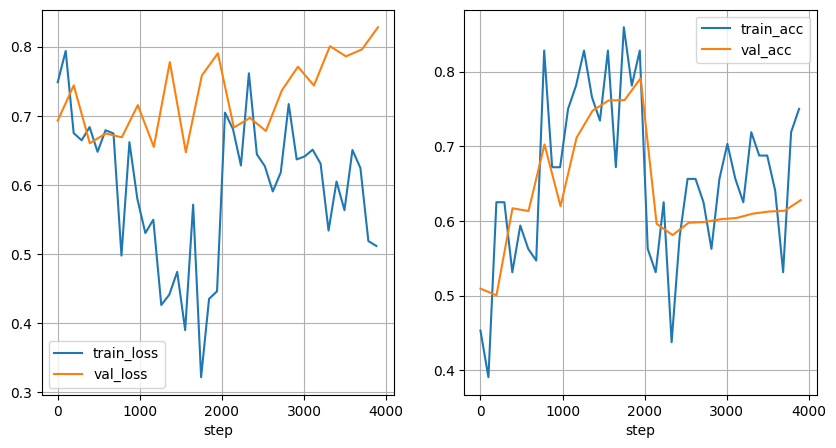

In [35]:
# 注意：损失值不一定在 [0, 1] 范围内，y 轴会根据实际数据自动调整
def plot_learning_curves(record_dict, sample_step=500):
    """
    绘制训练过程的学习曲线（损失和准确率随步数的变化）。

    参数：
        record_dict (dict)：training 函数返回的记录字典，包含 "train" 和 "val" 两个键
        sample_step (int)：训练集曲线每隔多少步取一个点绘制，避免点过密导致图形卡顿；默认 500
    """
    # pd.DataFrame(record_dict["train"])：将训练记录列表转换为 DataFrame（列为 loss/acc/step）
    # .set_index("step")：以 step 列作为 DataFrame 的行索引（横轴）
    # .iloc[::sample_step]：每隔 sample_step 行取一条记录，对稠密训练数据进行下采样
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]

    # 验证集记录较稀疏（约每半个 epoch 一条），无需下采样，直接全部使用
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # len(train_df.columns)：子图数量等于指标数量（loss 和 acc 各一张，共 2 张）
    fig_num = len(train_df.columns)

    # plt.subplots(1, fig_num)：创建 1 行 fig_num 列的子图布局
    # figsize=(5 * fig_num, 5)：每张子图宽 5 英寸，总宽度随指标数量自动缩放
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))

    for idx, item in enumerate(train_df.columns):  # 遍历每个指标列（loss 和 acc）
        # 绘制训练集曲线：横轴为 step，纵轴为指标值
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")

        # 绘制验证集曲线：与训练集曲线在同一子图上叠加显示
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")

        axs[idx].grid()    # 显示背景网格，方便读取数值
        axs[idx].legend()  # 显示图例，区分训练集和验证集曲线

        axs[idx].set_xlabel("step")  # 设置横轴标签为 "step"（全局训练步数）

    plt.show()  # 渲染并输出所有子图

sample_step=eval_step//2
# 使用训练记录绘制学习曲线，sample_step=eval_step//2 与评估间隔对齐，对训练集曲线做下采样
# 横坐标为全局训练步数（steps），而非 epoch 编号
plot_learning_curves(record, sample_step)

## 八、模型评估

### 8.1 加载最优模型并在测试集上评估

In [36]:
# 加载训练过程中保存的最优模型权重，在测试集上进行最终评估
# torch.load(path, map_location="cpu")：从磁盘加载序列化的模型参数字典
# map_location="cpu"：确保无论模型在 GPU 上训练，加载时都先映射到 CPU，避免设备不匹配错误
model.load_state_dict(torch.load("model_checkpoints/2_model/2_model_best.ckpt", map_location="cpu"))

# 切换到评估模式：关闭 Dropout 等训练专用层，确保推理结果的确定性和一致性
model.eval()

# 调用 evaluating 函数在完整测试集（test_dl）上计算平均损失和分类准确率
loss, acc = evaluating(model, test_dl, loss_fct)

# 格式化输出最终评估结果
# :.4f 保留 4 位小数，便于结果的精确对比
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.7904
accuracy: 0.7909
